In [1]:
import pandas as pd

In [5]:
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import mlflow
from mlflow.models import infer_signature

In [6]:
mlflow.set_tracking_uri(uri="http://127.0.0.1:5000")

In [16]:
X,y = datasets.load_iris(return_X_y=True)
#split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20)

In [18]:
#define the model hyperparameter
params = {"penalty":None, 'solver':'lbfgs','max_iter':1000, 'multi_class':'auto', 'random_state':8888}

#train the model
lr = LogisticRegression(**params)
lr.fit(X_train, y_train)

c:\Users\sarefin\development learnings\python\mlops mlflow udemy\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='auto', penalty=None,
                   random_state=8888)

In [19]:
#prediction on the test data
y_pred = lr.predict(X_test)
y_pred

array([1, 2, 2, 0, 2, 1, 1, 2, 1, 2, 1, 0, 2, 1, 0, 1, 2, 1, 0, 2, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0])

In [21]:
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.9333333333333333


In [22]:
#mlflow tracking
import mlflow.sklearn


mlflow.set_tracking_uri(uri="http://127.0.0.1:5000")

#create a new mlflow experiement
mlflow.set_experiment("MLFLOW Quickstart")

# Start an mlflow run
with mlflow.start_run():
    # log with hyperparameters
    mlflow.log_params(params)

    ## log the accuracy metrics
    mlflow.log_metric("accuracy", accuracy) #for multiple you can give k,v pair
    mlflow.set_tag("Training info", "Basic LR model for iris data")

    ##infer the model siganture
    signature = infer_signature(X_train, lr.predict(X_train))

    #log the model to save
    model_info=mlflow.sklearn.log_model(
        sk_model=lr,
        artifact_path='iris_model',##path to save
        signature=signature,
        input_example=X_train,
        registered_model_name='tracking-quickstart'
    )

2025/04/29 14:45:20 INFO mlflow.tracking.fluent: Experiment with name 'MLFLOW Quickstart' does not exist. Creating a new experiment.
Successfully registered model 'tracking-quickstart'.
2025/04/29 14:45:43 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: tracking-quickstart, version 1


🏃 View run carefree-flea-627 at: http://127.0.0.1:5000/#/experiments/428047793153508876/runs/b8157e160cd145acada72cf28eb5146b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/428047793153508876


Created version '1' of model 'tracking-quickstart'.


So we have tracked everything as experiement in the mlflow, lets run again and see how we can see all in mlflow

In [25]:
#define the model hyperparameter
params = {"penalty":'l2', 'solver':'sag','max_iter':1000, 'multi_class':'auto', 'random_state':5000}

#train the model
lr = LogisticRegression(**params)
lr.fit(X_train, y_train)

c:\Users\sarefin\development learnings\python\mlops mlflow udemy\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\sarefin\development learnings\python\mlops mlflow udemy\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='auto', random_state=5000,
                   solver='sag')

In [26]:
#prediction on the test data
y_pred = lr.predict(X_test)
y_pred

array([1, 2, 1, 0, 2, 1, 1, 2, 1, 1, 1, 0, 2, 1, 0, 1, 2, 1, 0, 2, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0])

In [27]:
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

1.0


In [28]:
#mlflow tracking
import mlflow.sklearn


mlflow.set_tracking_uri(uri="http://127.0.0.1:5000")

#create a new mlflow experiement
mlflow.set_experiment("MLFLOW Quickstart")

# Start an mlflow run
with mlflow.start_run():
    # log with hyperparameters
    mlflow.log_params(params)

    ## log the accuracy metrics
    mlflow.log_metric("accuracy", accuracy) #for multiple you can give k,v pair
    mlflow.set_tag("Training info", "Basic LR model for iris data")

    ##infer the model siganture
    signature = infer_signature(X_train, lr.predict(X_train))

    #log the model to save
    model_info=mlflow.sklearn.log_model(
        sk_model=lr,
        artifact_path='iris_model',##path to save
        signature=signature,
        input_example=X_train,
        registered_model_name='tracking-quickstart'
    )

Registered model 'tracking-quickstart' already exists. Creating a new version of this model...
2025/04/29 16:17:48 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: tracking-quickstart, version 2


🏃 View run calm-lamb-254 at: http://127.0.0.1:5000/#/experiments/428047793153508876/runs/74e5fcae3f954d10bf303c4ee7a824ba
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/428047793153508876


Created version '2' of model 'tracking-quickstart'.


In [29]:
model_info.model_uri

'runs:/74e5fcae3f954d10bf303c4ee7a824ba/iris_model'

# Inferencing and validating, 2 ways

code below is taken from the mlflow ui sample code

In [ ]:
import mlflow
from mlflow.models import Model

model_uri = 'runs:/74e5fcae3f954d10bf303c4ee7a824ba/iris_model'
# The model is logged with an input example
pyfunc_model = mlflow.pyfunc.load_model(model_uri)
input_data = pyfunc_model.input_example

# Verify the model with the provided input data using the logged dependencies.
# For more details, refer to:
# https://mlflow.org/docs/latest/models.html#validate-models-before-deployment
mlflow.models.predict(
    model_uri=model_uri,
    input_data=input_data,
    env_manager="local", # this is uv in mlflow ui, but change it to local to run in venv
)

2025/04/29 17:12:37 INFO mlflow.models.python_api: It is highly recommended to use `uv` as the environment manager for predicting with MLflow models as its performance is significantly better than other environment managers. Run `pip install uv` to install uv. See https://docs.astral.sh/uv/getting-started/installation for other installation methods.
2025/04/29 17:12:38 INFO mlflow.models.flavor_backend_registry: Selected backend for flavor 'python_function'


{"predictions": [2, 2, 1, 2, 1, 0, 1, 1, 0, 2, 2, 0, 2, 1, 2, 1, 2, 1, 1, 0, 1, 1, 1, 2, 1, 0, 2, 0, 0, 2, 1, 2, 2, 2, 0, 1, 0, 2, 2, 1, 1, 0, 2, 0, 0, 0, 2, 1, 1, 2, 1, 1, 2, 2, 2, 0, 2, 0, 2, 0, 2, 0, 0, 2, 0, 2, 0, 0, 2, 0, 0, 1, 1, 1, 1, 2, 1, 1, 0, 0, 2, 0, 0, 2, 0, 1, 0, 2, 1, 0, 2, 2, 2, 2, 0, 2, 0, 1, 2, 2, 2, 1, 0, 0, 2, 0, 1, 0, 2, 0, 1, 1, 2, 0, 2, 1, 2, 2, 0, 2]}

### Load the model back for prediction as a generic python function model

In [35]:
loaded_model = mlflow.pyfunc.load_model(model_info.model_uri)
predictions = loaded_model.predict(X_test)

iris_features_name = datasets.load_iris().feature_names
result = pd.DataFrame(X_test, columns=iris_features_name)
result['actual_class']=y_test
result['predicted_class']=predictions

In [37]:
result.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),actual_class,predicted_class
0,6.1,2.8,4.7,1.2,1,1
1,6.7,3.0,5.2,2.3,2,2
2,6.2,2.2,4.5,1.5,1,1
3,5.5,3.5,1.3,0.2,0,0
4,5.8,2.7,5.1,1.9,2,2


# Model registry

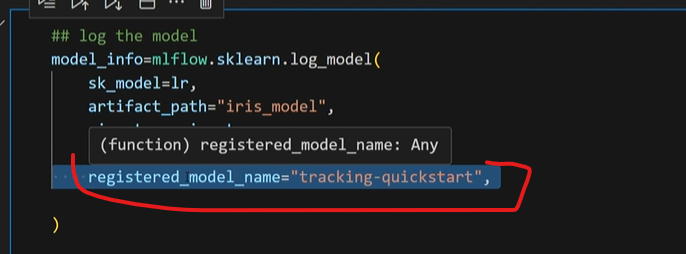
when you specify this parameter, mlflow starts to track this as registered model, and can be seein in the ui. 
if you run multiple run of this, then mlflow will keep this incrmeental versions.
but dont do this register unless the model is stable and accuracy is good

example of not registering the model, but still tracking as run

In [38]:
#mlflow tracking
import mlflow.sklearn


mlflow.set_tracking_uri(uri="http://127.0.0.1:5000")

#create a new mlflow experiement
mlflow.set_experiment("MLFLOW Quickstart")

# Start an mlflow run
with mlflow.start_run():
    # log with hyperparameters
    mlflow.log_params(params)

    ## log the accuracy metrics
    mlflow.log_metric("accuracy", 0.8) #for testing
    mlflow.set_tag("Training info2", "Basic LR model for iris data")

    ##infer the model siganture
    signature = infer_signature(X_train, lr.predict(X_train))

    #log the model to save
    model_info=mlflow.sklearn.log_model(
        sk_model=lr,
        artifact_path='iris_model',##path to save
        signature=signature,
        input_example=X_train
       
    )

🏃 View run polite-owl-741 at: http://127.0.0.1:5000/#/experiments/428047793153508876/runs/7afbd492624245839a15a4ebb8814d95
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/428047793153508876


when u run a model like this, without registering, ui also gives u option to register it.




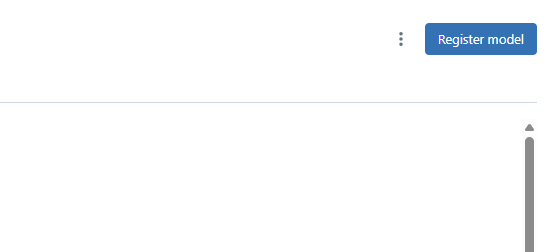

### Inferencing a model from model registry(where versions are tracked)

In [40]:
import mlflow.sklearn
import mlflow.sklearn
model_name='tracking-quickstart'
model_version='latest'#automatically picks latest
model_uri=f'models:/{model_name}/{model_version}'
model = mlflow.sklearn.load_model(model_uri)

In [41]:
model_uri

'models:/tracking-quickstart/latest'

In [42]:
y_pred_new=model.predict(X_test)

In [43]:
y_pred_new

array([1, 2, 1, 0, 2, 1, 1, 2, 1, 1, 1, 0, 2, 1, 0, 1, 2, 1, 0, 2, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0])

# Logistic regression

Key Concepts of Logistic Regression
Binary Classification: Logistic regression is commonly used for problems where the outcome is binary (e.g., yes/no, true/false, 0/1).

Sigmoid Function: The core of logistic regression is the sigmoid function, which maps any real-valued number into a value between 0 and 1. The sigmoid function is defined as:



Probability Output: The output of logistic regression is a probability value that indicates the likelihood of the sample belonging to the positive class (e.g., class 1).

Decision Boundary: Based on the probability output, logistic regression applies a threshold (usually 0.5) to decide the class label. If the probability is greater than 0.5, the sample is classified as the positive class; otherwise, it's classified as the negative class.

Logistic regression can indeed be extended to handle multi-class classification problems, like the Iris dataset which has three classes (Setosa, Versicolor, and Virginica). This extension is often referred to as multinomial logistic regression or softmax regression.

Multinomial Logistic Regression
In scikit-learn, the LogisticRegression class can handle multi-class classification by setting the multi_class parameter. The two common strategies are:

One-vs-Rest (OvR): This strategy fits one classifier per class, with the samples of that class as positive samples and all other samples as negatives.
Softmax (Multinomial): This strategy fits a single classifier with multiple classes directly.